# Flight Price Prediction — Model Building & Evaluation

Trains 7 regressors, runs cross-validation, plots residuals, and tunes the best performer with GridSearchCV.

## 1. Imports & Load Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

from utils import (
    evaluate_model, plot_residuals, plot_pred_vs_actual,
    cross_validate_model, compare_models,
)

sns.set_style('whitegrid')
%matplotlib inline

In [2]:
df = pd.read_csv('data/flights_cleaned.csv')
print('Shape:', df.shape)
df.head()

Shape: (50000, 31)


,stops,duration,days_left,price,log_duration,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,...,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai,class_Economy
0,1,19.75,40,7366,3.032546,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
1,1,9.83,42,64831,2.382320,0,0,0,0,1,...,0,0,0,1,0,0,0,0,1,0
2,1,10.50,41,6195,2.442347,0,0,0,0,1,...,0,0,0,1,0,0,0,0,0,1
3,1,14.50,14,60160,2.740840,0,0,0,0,1,...,0,0,1,0,0,1,0,0,0,0
4,1,8.25,20,6578,2.224624,1,0,0,0,0,...,0,0,0,1,0,0,0,0,1,1


## 2. Train / Test Split & Scaling

In [3]:
X = df.drop(columns=['price'])
y = df['price']
print('Features:', X.shape[1])
print('Target stats:'); print(y.describe().round(2))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Train:', X_train.shape, 'Test:', X_test.shape)

Features: 30
Target stats:
count     50000.00
mean      20827.47
std       22658.67
min        1105.00
25%        4784.00
50%        7424.00
75%       42521.00
max      114705.00
Name: price, dtype: float64
Train: (40000, 30) Test: (10000, 30)


## 3. Train 7 Regressors

In [4]:
results = []
models = {}


  Linear Regression
  MAE   : 4566.4106
  RMSE  : 6800.3905
  R2    : 0.9106
  MAPE  : 0.4551


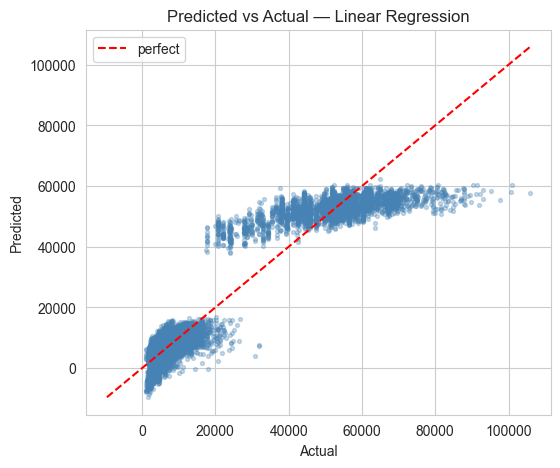

In [5]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
results.append(evaluate_model('Linear Regression', y_test, y_pred))
models['Linear Regression'] = ('scaled', lr)
plot_pred_vs_actual(y_test, y_pred, 'Linear Regression'); plt.show()


  Ridge
  MAE   : 4566.3339
  RMSE  : 6800.3930
  R2    : 0.9106
  MAPE  : 0.4551


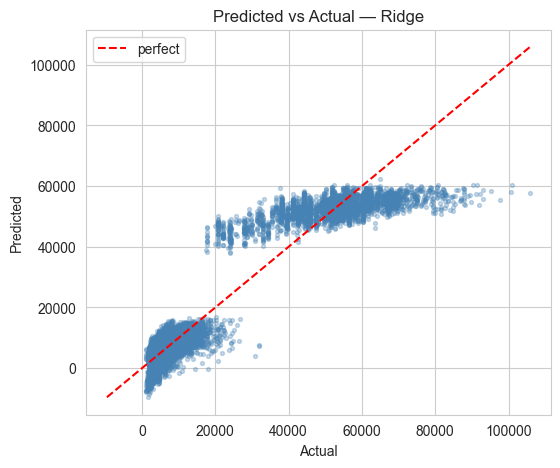

In [6]:
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_scaled, y_train)
y_pred = ridge.predict(X_test_scaled)
results.append(evaluate_model('Ridge', y_test, y_pred))
models['Ridge'] = ('scaled', ridge)
plot_pred_vs_actual(y_test, y_pred, 'Ridge'); plt.show()


  Lasso
  MAE   : 4566.3016
  RMSE  : 6800.4018
  R2    : 0.9106
  MAPE  : 0.4551


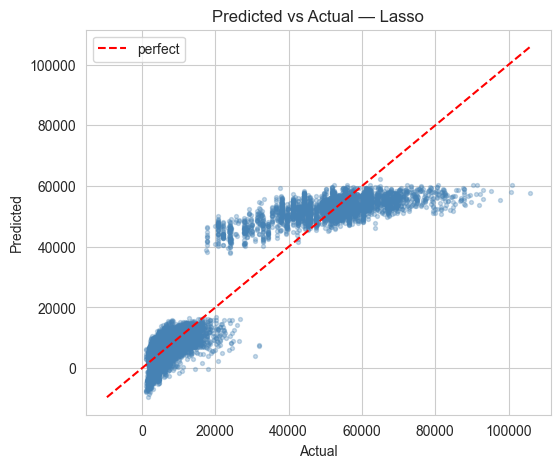

In [7]:
lasso = Lasso(alpha=0.1, random_state=42, max_iter=10000)
lasso.fit(X_train_scaled, y_train)
y_pred = lasso.predict(X_test_scaled)
results.append(evaluate_model('Lasso', y_test, y_pred))
models['Lasso'] = ('scaled', lasso)
plot_pred_vs_actual(y_test, y_pred, 'Lasso'); plt.show()


  Decision Tree
  MAE   : 2605.6413
  RMSE  : 4731.3272
  R2    : 0.9567
  MAPE  : 0.1710


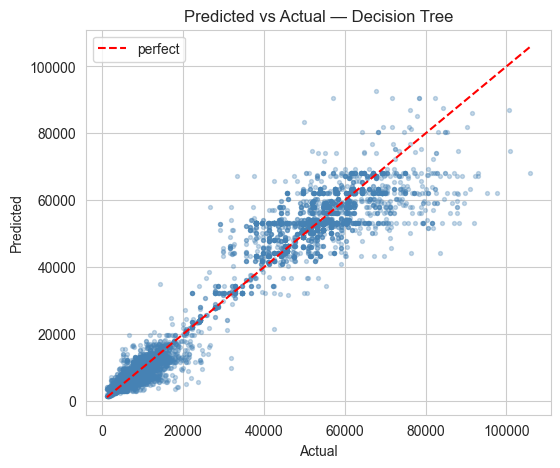

In [8]:
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
results.append(evaluate_model('Decision Tree', y_test, y_pred))
models['Decision Tree'] = ('raw', dt)
plot_pred_vs_actual(y_test, y_pred, 'Decision Tree'); plt.show()


  Random Forest
  MAE   : 1606.5895
  RMSE  : 3355.9414
  R2    : 0.9782
  MAPE  : 0.1106


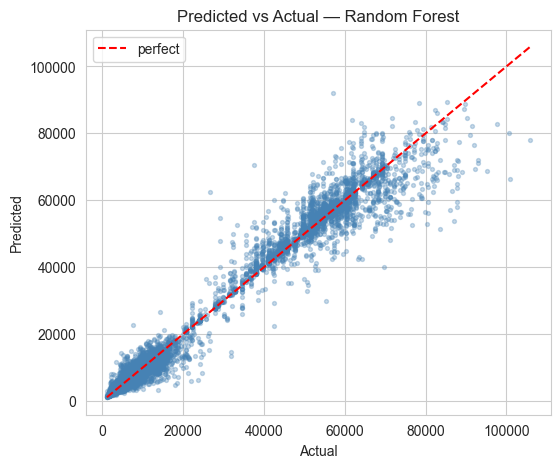

In [9]:
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
results.append(evaluate_model('Random Forest', y_test, y_pred))
models['Random Forest'] = ('raw', rf)
plot_pred_vs_actual(y_test, y_pred, 'Random Forest'); plt.show()

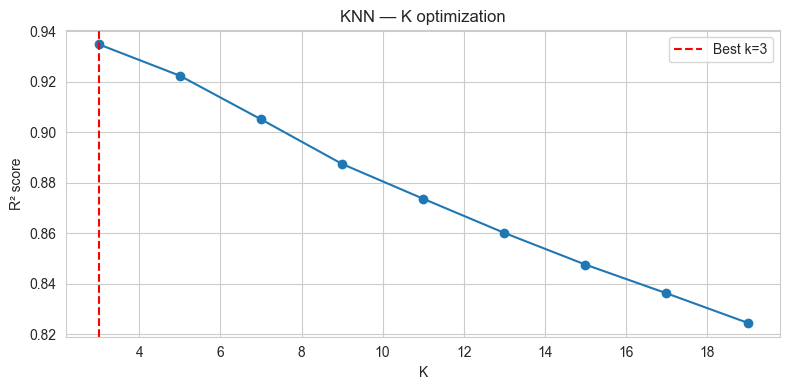


  KNN (k=3)
  MAE   : 2783.5626
  RMSE  : 5807.1645
  R2    : 0.9348
  MAPE  : 0.1982


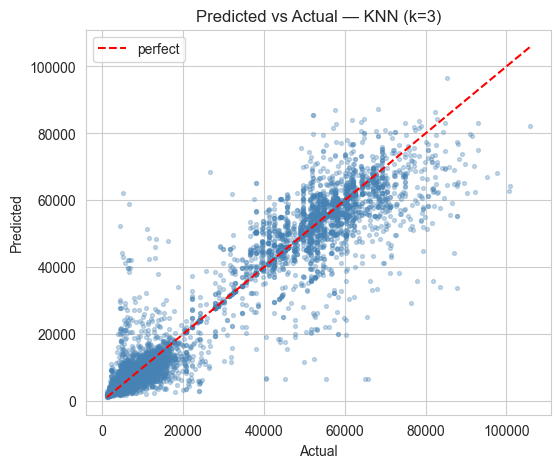

In [10]:
k_range = range(3, 21, 2)
from sklearn.metrics import r2_score
k_scores = []
for k in k_range:
    knn_t = KNeighborsRegressor(n_neighbors=k, n_jobs=-1)
    knn_t.fit(X_train_scaled, y_train)
    k_scores.append(r2_score(y_test, knn_t.predict(X_test_scaled)))
best_k = list(k_range)[int(np.argmax(k_scores))]
plt.figure(figsize=(8, 4)); plt.plot(list(k_range), k_scores, marker='o')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.xlabel('K'); plt.ylabel('R² score'); plt.title('KNN — K optimization')
plt.legend(); plt.tight_layout(); plt.show()
knn = KNeighborsRegressor(n_neighbors=best_k, n_jobs=-1)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
knn_label = f'KNN (k={best_k})'
results.append(evaluate_model(knn_label, y_test, y_pred))
models[knn_label] = ('scaled', knn)
plot_pred_vs_actual(y_test, y_pred, knn_label); plt.show()


  Gradient Boosting
  MAE   : 2904.7026
  RMSE  : 4878.1894
  R2    : 0.9540
  MAPE  : 0.2012


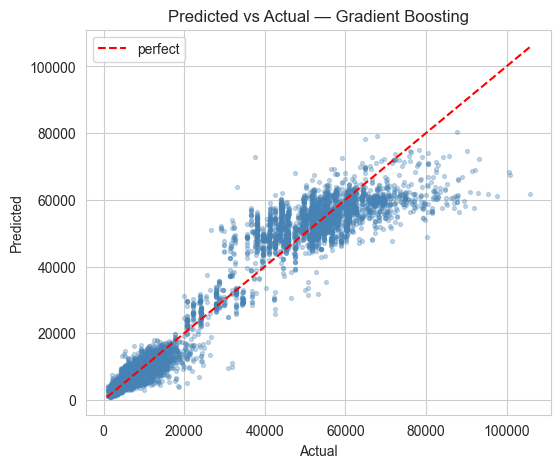

In [11]:
gb = GradientBoostingRegressor(n_estimators=200, random_state=42)
gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)
results.append(evaluate_model('Gradient Boosting', y_test, y_pred))
models['Gradient Boosting'] = ('raw', gb)
plot_pred_vs_actual(y_test, y_pred, 'Gradient Boosting'); plt.show()

## 4. Feature Importance — Tree Models

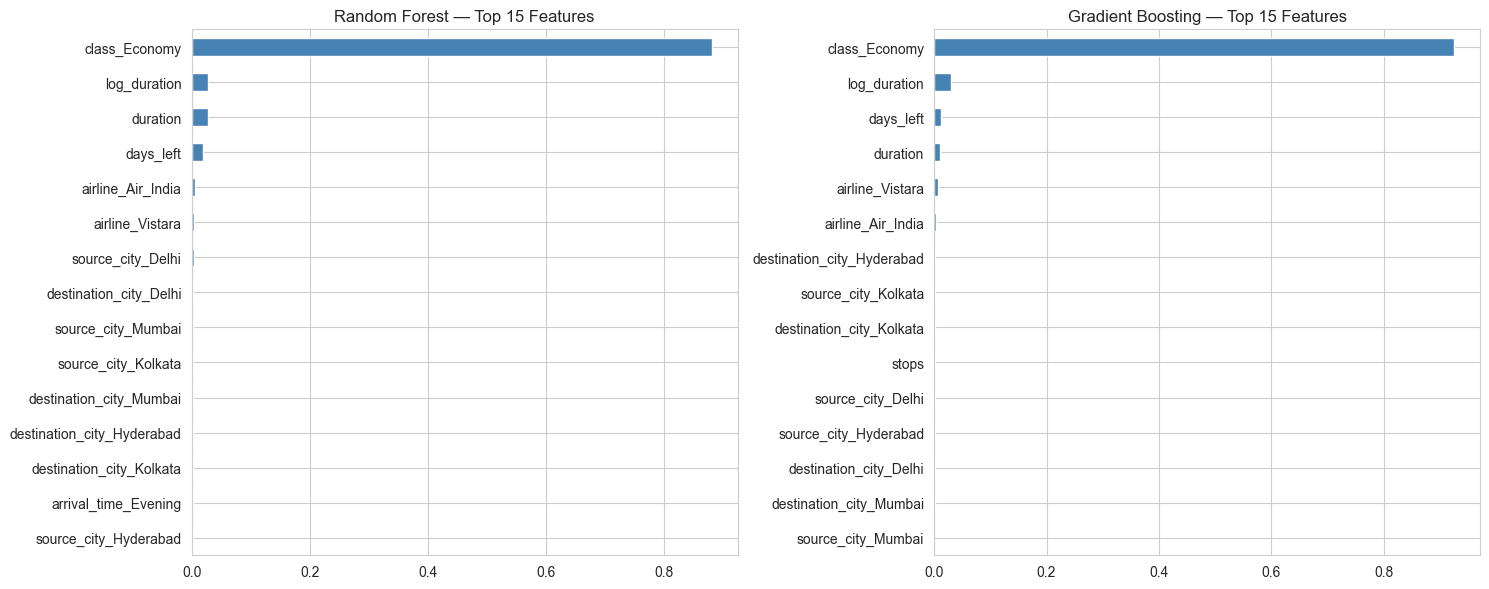

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (name, model) in zip(axes, [('Random Forest', rf), ('Gradient Boosting', gb)]):
    importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True).tail(15)
    importances.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{name} — Top 15 Features')
plt.tight_layout(); plt.show()

## 5. Model Comparison

In [13]:
comparison = compare_models(results)
comparison

,Model,MAE,RMSE,R2,MAPE
0,Random Forest,1606.589481,3355.941401,0.978236,0.110633
1,Decision Tree,2605.641303,4731.327235,0.956741,0.170987
2,Gradient Boosting,2904.702577,4878.189415,0.954013,0.201188
3,KNN (k=3),2783.562567,5807.164483,0.934831,0.198176
4,Linear Regression,4566.410579,6800.390502,0.910632,0.455137
5,Ridge,4566.333943,6800.393037,0.910632,0.455104
6,Lasso,4566.301643,6800.401817,0.910632,0.455095


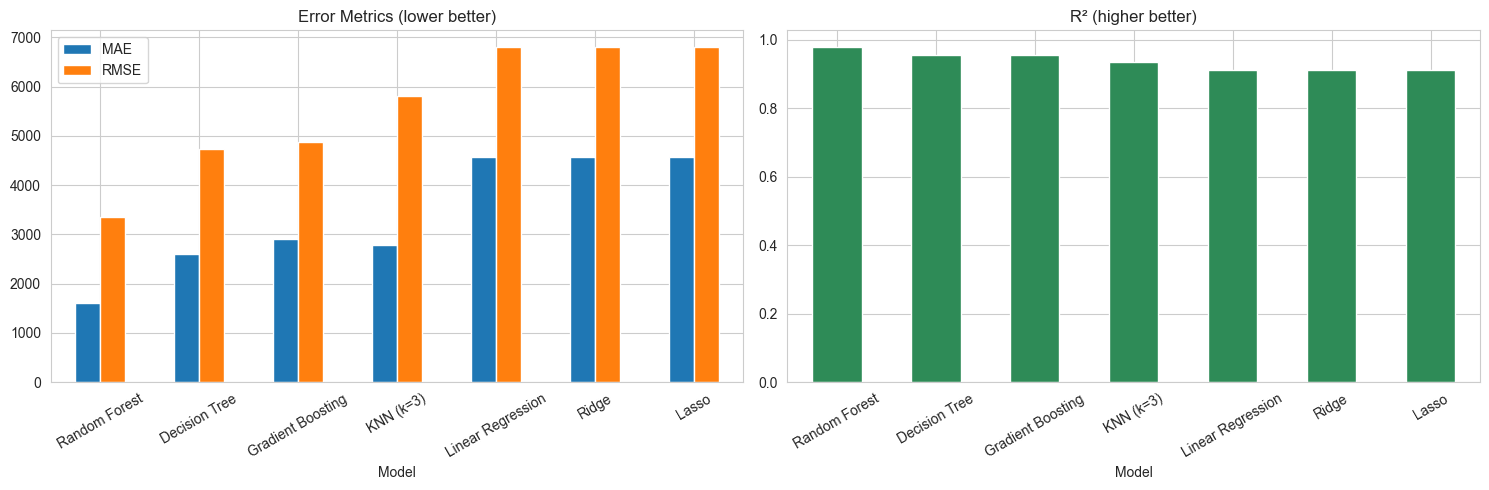

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
comparison.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Error Metrics (lower better)')
axes[0].tick_params(axis='x', rotation=30)
comparison.set_index('Model')[['R2']].plot(kind='bar', ax=axes[1], color='seagreen', legend=False)
axes[1].set_title('R² (higher better)')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

## 6. 5-Fold Cross-Validation

In [15]:
cv_idx = np.random.RandomState(42).choice(len(X), size=min(len(X), 8000), replace=False)
X_cv, y_cv = X.iloc[cv_idx], y.iloc[cv_idx]
X_cv_scaled = scaler.fit_transform(X_cv)
print('CV sample size:', len(X_cv))

CV sample size: 8000


In [16]:
cv_scores = {}
for name, (kind, model) in models.items():
    if kind == 'scaled':
        scores = cross_val_score(model, X_cv_scaled, y_cv, cv=5, scoring='r2', n_jobs=-1)
    else:
        scores = cross_val_score(model, X_cv, y_cv, cv=5, scoring='r2', n_jobs=-1)
    cv_scores[name] = scores
    print(f'{name:25s} mean R² = {scores.mean():.4f} (+/- {scores.std():.4f})')

Linear Regression         mean R² = 0.9111 (+/- 0.0037)


Ridge                     mean R² = 0.9111 (+/- 0.0037)


Lasso                     mean R² = 0.9111 (+/- 0.0037)


Decision Tree             mean R² = 0.9470 (+/- 0.0025)


Random Forest             mean R² = 0.9615 (+/- 0.0022)


KNN (k=3)                 mean R² = 0.7131 (+/- 0.0110)


Gradient Boosting         mean R² = 0.9527 (+/- 0.0016)


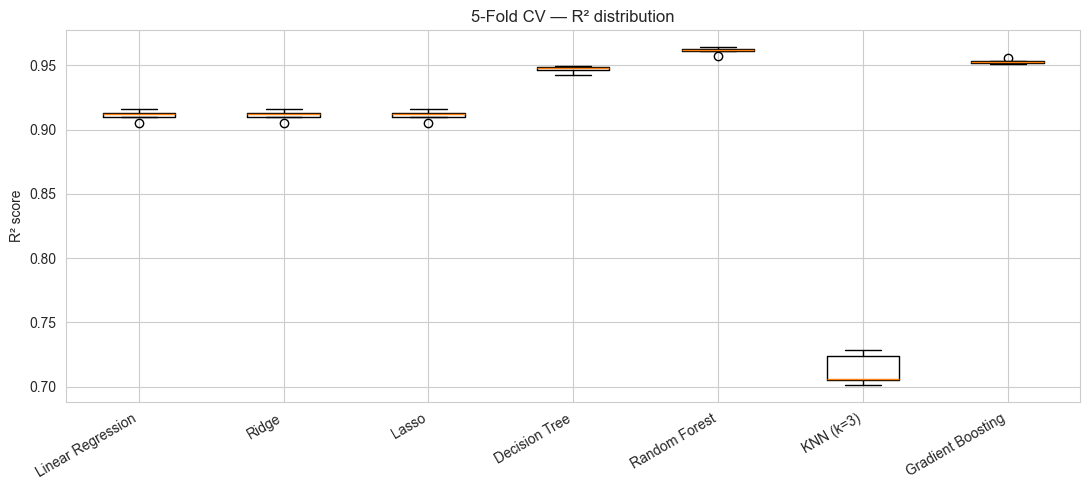

In [17]:
plt.figure(figsize=(11, 5))
plt.boxplot([cv_scores[k] for k in cv_scores], labels=list(cv_scores.keys()))
plt.xticks(rotation=30, ha='right'); plt.ylabel('R² score')
plt.title('5-Fold CV — R² distribution'); plt.tight_layout(); plt.show()

## 7. Residuals — Best Model

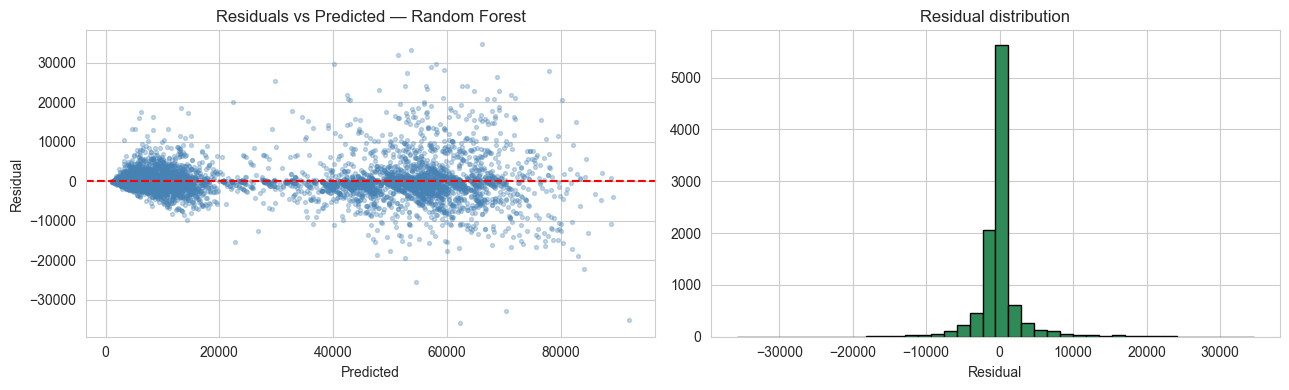

In [18]:
best_model_name = comparison.iloc[0]['Model']
kind, best_pre = models[best_model_name]
Xt = X_test_scaled if kind == 'scaled' else X_test
y_pred_best = best_pre.predict(Xt)
plot_residuals(y_test, y_pred_best, best_model_name); plt.show()

## 8. Hyperparameter Tuning — Best Performer

Best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
Best CV R²: 0.9763

  Random Forest (Tuned)
  MAE   : 1606.5895
  RMSE  : 3355.9414
  R2    : 0.9782
  MAPE  : 0.1106


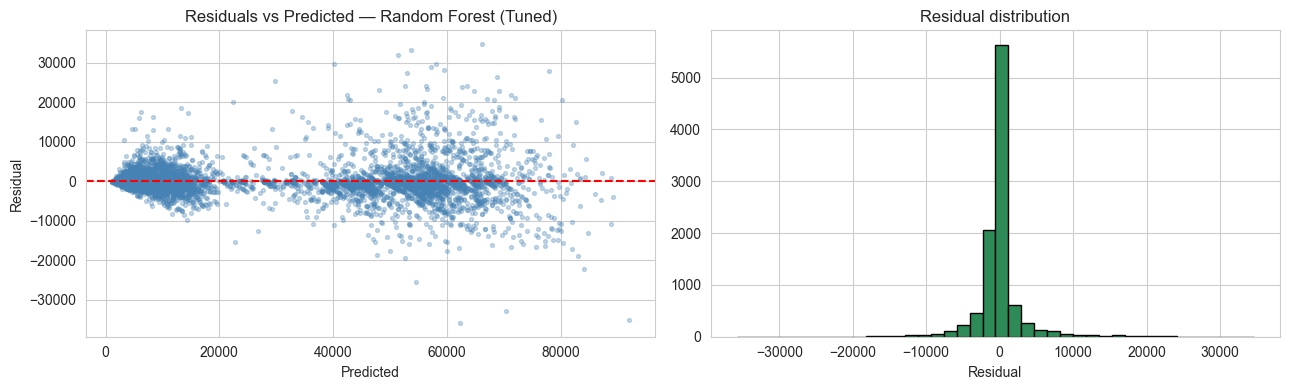

In [19]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 15, 25],
    'min_samples_leaf': [1, 2],
}
rf_tuned = RandomForestRegressor(random_state=42, n_jobs=-1)
grid = GridSearchCV(rf_tuned, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=0)
grid.fit(X_train, y_train)
print('Best params:', grid.best_params_)
print('Best CV R²:', round(grid.best_score_, 4))
best = grid.best_estimator_
y_pred = best.predict(X_test)
tuned_metrics = evaluate_model('Random Forest (Tuned)', y_test, y_pred)
results.append(tuned_metrics)
plot_residuals(y_test, y_pred, 'Random Forest (Tuned)'); plt.show()

## 9. Tuned Model — Feature Importance

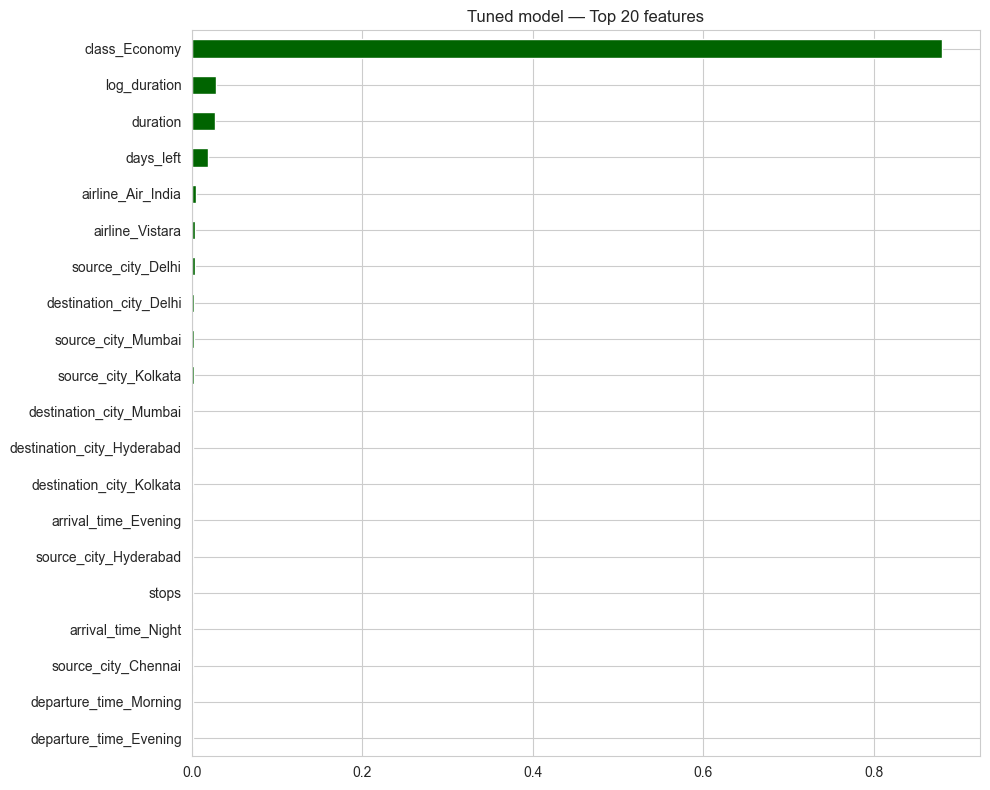

In [20]:
if hasattr(best, 'feature_importances_'):
    importances = pd.Series(best.feature_importances_, index=X.columns).sort_values(ascending=True).tail(20)
    plt.figure(figsize=(10, 8))
    importances.plot(kind='barh', color='darkgreen')
    plt.title('Tuned model — Top 20 features'); plt.tight_layout(); plt.show()
elif hasattr(best, 'coef_'):
    importances = pd.Series(np.abs(best.coef_), index=X.columns).sort_values(ascending=True).tail(20)
    plt.figure(figsize=(10, 8))
    importances.plot(kind='barh', color='darkgreen')
    plt.title('Tuned model — Top 20 |coefficients|'); plt.tight_layout(); plt.show()

## 10. Sample Prediction

In [21]:
sample = X_test.iloc[:5].copy()
preds = best.predict(sample)
out = pd.DataFrame({'Predicted': preds.round(2), 'Actual': y_test.iloc[:5].values.round(2)})
out['AbsError'] = (out['Predicted'] - out['Actual']).abs().round(2)
out

,Predicted,Actual,AbsError
0,6776.33,5352,1424.33
1,9279.26,9433,153.74
2,9140.83,14301,5160.17
3,9072.30,8719,353.30
4,62747.92,56273,6474.92


## 11. Final Summary

In [22]:
final = compare_models(results)
final

,Model,MAE,RMSE,R2,MAPE
0,Random Forest,1606.589481,3355.941401,0.978236,0.110633
1,Random Forest (Tuned),1606.589481,3355.941401,0.978236,0.110633
2,Decision Tree,2605.641303,4731.327235,0.956741,0.170987
3,Gradient Boosting,2904.702577,4878.189415,0.954013,0.201188
4,KNN (k=3),2783.562567,5807.164483,0.934831,0.198176
5,Linear Regression,4566.410579,6800.390502,0.910632,0.455137
6,Ridge,4566.333943,6800.393037,0.910632,0.455104
7,Lasso,4566.301643,6800.401817,0.910632,0.455095


### Key Takeaways

- Flight Price Prediction: regression on `price`.
- 7 regressors + 1 tuned variant evaluated on MAE / RMSE / R² / MAPE.
- Tree-based models highlight the most predictive features.
- Predicted-vs-actual scatter plots reveal where models systematically over/underestimate.

### Next Steps

- Try gradient boosters (XGBoost, LightGBM) for further gains.
- Apply log-transform on skewed targets and re-fit.
- Add domain-specific feature engineering.